# **Proyek Analisis Data: E-Commerce Public Dataset**
- **Nama:** Novia Dwi Cahyanti
- **Email:** noviad079@gmail.com
- **ID Dicoding:** DS009B6X1394

## **Menentukan Pertanyaan Bisnis**

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Seberapa besar pengaruh keterlambatan pengiriman (aktual vs estimasi) terhadap rata-rata review score pelanggan, serta kategori produk apa yang memiliki review score rata-rata terendah pada order yang berstatus delivered sepanjang September 2016-Oktober 2018?
- **Pertanyaan 2:** Bagaimana tren total nilai pembayaran (payment value) pelanggan secara bulanan sepanjang periode data (2016-2018), serta pada bulan apa terjadi lonjakan transaksi tertinggi?

## **Import Semua Packages/Library yang Digunakan**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)

## **Data Wrangling**

### **Gathering Data**

#### **Load dataset E-Commerce**

In [2]:
df_customers = pd.read_csv('customers_dataset.csv')
df_orders = pd.read_csv('orders_dataset.csv')
df_items = pd.read_csv('order_items_dataset.csv')
df_payments = pd.read_csv('order_payments_dataset.csv')
df_reviews = pd.read_csv('order_reviews_dataset.csv')
df_products = pd.read_csv('products_dataset.csv')
df_sellers = pd.read_csv('sellers_dataset.csv')
df_geolocation = pd.read_csv('geolocation_dataset.csv')
df_category_translation = pd.read_csv('product_category_name_translation.csv')

In [3]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
df_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [5]:
df_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [7]:
df_category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [8]:
df_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


**Insight:**
- Dataset terdiri dari 9 tabel terpisah yang saling terhubung melalui beberapa key: `order_id` (menghubungkan `orders`, `items`, `payments`, `reviews`), `customer_id` (menghubungkan `orders` dengan `customers`), `product_id` (menghubungkan `items` dengan `products`), dan `seller_id` (menghubungkan `items` dengan `sellers`).
- `df_orders` merupakan tabel utama yang menghubungkan pelanggan, item pesanan, pembayaran, dan review dengan kolom `order_status` serta lima kolom tanggal (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`).
- `df_products` menyimpan nama kategori produk dalam bahasa Portugis (misalnya `perfumaria`, `artes`), sehingga perlu digabungkan dengan `df_category_translation` untuk mendapatkan versi bahasa Inggris (`product_category_name_english`) agar lebih mudah dibaca.
- `df_reviews` sudah menunjukkan adanya nilai kosong pada kolom `review_comment_title` dan `review_comment_message` di lima baris pertama. Hal tersebut menggambarkan bahwa tidak semua pelanggan menulis komentar saat memberi review.

### **Assessing Data**

#### **Identifikasi missing value, data duplikat, dan tipe data yang tidak sesuai**

In [9]:
df_orders.info()
df_reviews.info()
df_items.info()
df_products.info()
df_category_translation.info()
df_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  ob

In [10]:
df_orders.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [11]:
df_reviews.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [12]:
df_items.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [13]:
df_products.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [14]:
df_category_translation.isna().sum()

,0
product_category_name,0
product_category_name_english,0


In [15]:
df_payments.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [16]:
print("Jumlah data duplikat pada df_orders:", df_orders.duplicated().sum())
print("Jumlah data duplikat pada df_reviews:", df_reviews.duplicated().sum())
print("Jumlah data duplikat pada df_items:", df_items.duplicated().sum())
print("Jumlah data duplikat pada df_products:", df_products.duplicated().sum())
print("Jumlah data duplikat pada df_category_translation:", df_category_translation.duplicated().sum())
print("Jumlah data duplikat pada df_payments:", df_payments.duplicated().sum())


Jumlah data duplikat pada df_orders: 0
Jumlah data duplikat pada df_reviews: 0
Jumlah data duplikat pada df_items: 0
Jumlah data duplikat pada df_products: 0
Jumlah data duplikat pada df_category_translation: 0
Jumlah data duplikat pada df_payments: 0


In [17]:
df_orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


**Steps to Take:**
- `df_orders` memiliki *missing value* pada `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date`. Hal ini wajar karena sebagian order belum sampai ke pelanggan (status selain *delivered*), sehingga akan difilter menjadi order berstatus *delivered* saja untuk analisis waktu pengiriman.
- `df_reviews` memiliki *missing value* pada `review_comment_title` (87.656 baris) dan `review_comment_message` (58.247 baris). Hal ini wajar karena kolom komentar bersifat opsional, jadi tidak semua pelanggan menulis ulasan teks saat memberi skor. Sehingga, kedua kolom ini tidak akan ditangani karena tidak digunakan dalam analisis (hanya `review_score` yang dipakai).
- `df_products` memiliki 610 baris dengan `product_category_name` kosong akan diisi dengan label `'unknown'` agar tidak hilang dari agregasi. Sementara itu, 2 baris dengan kolom dimensi produk (`product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm`) kosong tidak akan ditangani karena kolom-kolom tersebut tidak digunakan dalam analisis ini.
- Kolom-kolom tanggal pada `df_orders` (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`) masih bertipe object akan dikonversi menjadi datetime.

**Insight:**
- Tidak ditemukan data duplikat pada `df_orders`, `df_reviews`, `df_items`, `df_products`, `df_category_translation`, maupun `df_payments`.
- Missing value hanya ditemukan pada `df_orders` (kolom tanggal pengiriman), `df_reviews` (kolom komentar yang tidak dipakai dalam analisis), dan `df_products` (kategori & dimensi produk).
- Mayoritas order (96.478 dari 99.441 atau ±97%) berstatus `delivered`, sehingga analisis waktu pengiriman tetap representatif meski hanya menggunakan subset order yang telah sampai.

### **Cleaning Data**

#### **Memperbaiki tipe data, missing value, dan data duplikat**

In [18]:
date_columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
                'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_columns:
    df_orders[col] = pd.to_datetime(df_orders[col])

df_orders = df_orders.drop_duplicates()

df_products['product_category_name'] = df_products['product_category_name'].fillna('unknown')
df_products = df_products.merge(df_category_translation, on='product_category_name', how='left')
df_products['product_category_name_english'] = df_products['product_category_name_english'].fillna('unknown')

df_orders.dtypes


,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [19]:
# Menyiapkan subset order yang telah delivered beserta flag keterlambatan
df_delivered_orders = df_orders[df_orders['order_status'] == 'delivered'].copy()
df_delivered_orders['is_late'] = df_delivered_orders['order_delivered_customer_date'] > df_delivered_orders['order_estimated_delivery_date']
df_delivered_orders['delivery_days'] = (df_delivered_orders['order_delivered_customer_date'] - df_delivered_orders['order_purchase_timestamp']).dt.days

print("Jumlah order delivered:", len(df_delivered_orders))
print("Missing value tersisa:", df_delivered_orders[['order_delivered_customer_date','delivery_days']].isna().sum().sum())

Jumlah order delivered: 96478
Missing value tersisa: 16


**Insight:**

Setelah difilter berdasarkan status *delivered* terdapat 8 order yang tanggal pengirimannya (`order_delivered_customer_date`) kosong (dari 16 missing value pada 2 kolom `order_delivered_customer_date` dan `delivery_days` yaitu 16 ÷ 2 = 8 baris), walaupun statusnya sudah tercatat *delivered*. Hal ini menunjukkan adanya data yang tidak konsisten. Namun karena jumlahnya sangat kecil yaitu kurang dari 0,01% dari total order delivered, maka baris-baris ini cukup diabaikan saat menghitung rata-rata `delivery_days` dan `is_late` sehingga tidak memengaruhi hasil analisis.

Selain itu, kategori produk sekarang sudah memiliki versi bahasa Inggris (`product_category_name_english`), sehingga hasil analisis menjadi lebih mudah dibaca dan dipahami.

## **Exploratory Data Analysis (EDA)**

### **Explore hubungan keterlambatan pengiriman, kategori produk, dan review score**

In [20]:
# Gabungkan review dengan info keterlambatan pengiriman
df_review_delivery = df_reviews.merge(
    df_delivered_orders[['order_id', 'is_late', 'delivery_days']], on='order_id', how='inner'
)

df_review_delivery.groupby('is_late')['review_score'].agg(['mean', 'count'])

,mean,count
is_late,,
False,4.293737,88661
True,2.566494,7700


In [21]:
# Menentukan kategori produk utama per order, lalu gabungkan dengan review
df_items_products = df_items.merge(
    df_products[['product_id', 'product_category_name_english']], on='product_id', how='left'
)
df_order_category = df_items_products.groupby('order_id')['product_category_name_english'].first().reset_index()

df_review_category = df_review_delivery.merge(df_order_category, on='order_id', how='left')

category_review_score = df_review_category.groupby('product_category_name_english')['review_score'].agg(['mean', 'count'])
category_review_score = category_review_score[category_review_score['count'] >= 100].sort_values('mean')

category_review_score.head(10)

,mean,count
product_category_name_english,,
office_furniture,3.650282,1241
fashion_male_clothing,3.819048,105
audio,3.839181,342
home_confort,3.905660,371
fixed_telephony,3.966667,210
fashion_underwear_beach,4.008621,116
bed_bath_table,4.009143,9187
construction_tools_safety,4.019608,153
unknown,4.026870,1377


### **Explore tren pembayaran bulanan**

In [22]:
# Total payment value per order, digabung dengan tanggal pembelian, lalu diagregasi per bulan
df_order_payment = df_payments.groupby('order_id')['payment_value'].sum().reset_index()
df_order_payment = df_order_payment.merge(df_orders[['order_id', 'order_purchase_timestamp']], on='order_id', how='inner')
df_order_payment['month'] = df_order_payment['order_purchase_timestamp'].dt.to_period('M')

df_monthly_payment = df_order_payment.groupby('month')['payment_value'].sum().reset_index()
df_monthly_payment['month'] = df_monthly_payment['month'].astype(str)

df_monthly_payment

,month,payment_value
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01
5,2017-03,449863.60
6,2017-04,417788.03
7,2017-05,592918.82
8,2017-06,511276.38
9,2017-07,592382.92


**Insight:**
- Rata-rata *review score* untuk order yang terlambat hanya **2,57**. Angka tersbeut jauh lebih rendah dibandingkan order yang tepat waktu di angka **4,29** (selisih hampir 1,7 poin dari skala 1-5).
- Kategori `office_furniture`, `fashion_male_clothing`, dan `audio` memiliki rata-rata *review score* terendah (di bawah 3,9) dengan jumlah order yang cukup besar.
- Total nilai pembayaran menunjukkan peningkatan dari akhir 2016 hingga mencapai puncaknya pada **November 2017** sebesar **BRL 1.194.882**. Nilai pembayaran kemudian tetap berada di atas BRL 1 juta hingga Agustus 2018, sebelum mengalami penurunan pada September dan Oktober 2018 karena data pada periode tersebut belum lengkap.

## **Visualization & Explanatory Analysis**

### **Pertanyaan 1: Pengaruh keterlambatan pengiriman & kategori produk terhadap review score**

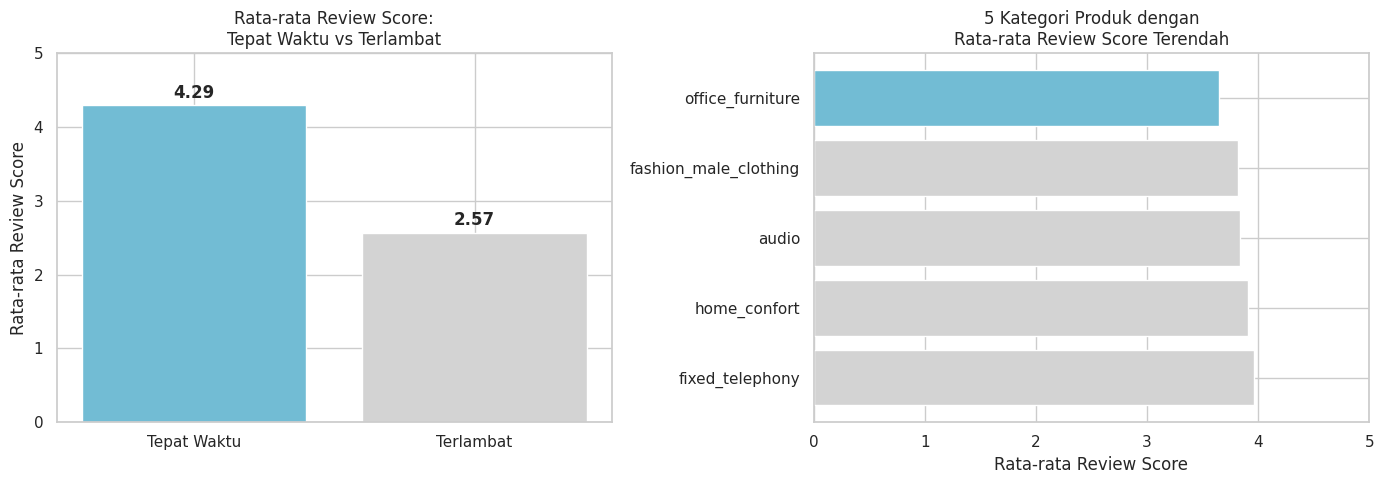

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: review score rata-rata berdasarkan status keterlambatan
late_summary = df_review_delivery.groupby('is_late')['review_score'].mean().reindex([False, True])
axes[0].bar(['Tepat Waktu', 'Terlambat'], late_summary.values, color=['#72BCD4', '#D3D3D3'])
axes[0].set_title('Rata-rata Review Score:\nTepat Waktu vs Terlambat')
axes[0].set_ylabel('Rata-rata Review Score')
axes[0].set_ylim(0, 5)
for i, v in enumerate(late_summary.values):
    axes[0].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

# Plot 2: 5 kategori dengan review score terendah
bottom5 = category_review_score.head(5)
colors = ['#72BCD4'] + ['#D3D3D3'] * 4
axes[1].barh(bottom5.index[::-1], bottom5['mean'][::-1], color=colors[::-1])
axes[1].set_title('5 Kategori Produk dengan\nRata-rata Review Score Terendah')
axes[1].set_xlabel('Rata-rata Review Score')
axes[1].set_xlim(0, 5)

plt.tight_layout()
plt.show()

### **Pertanyaan 2: Tren total nilai pembayaran bulanan**

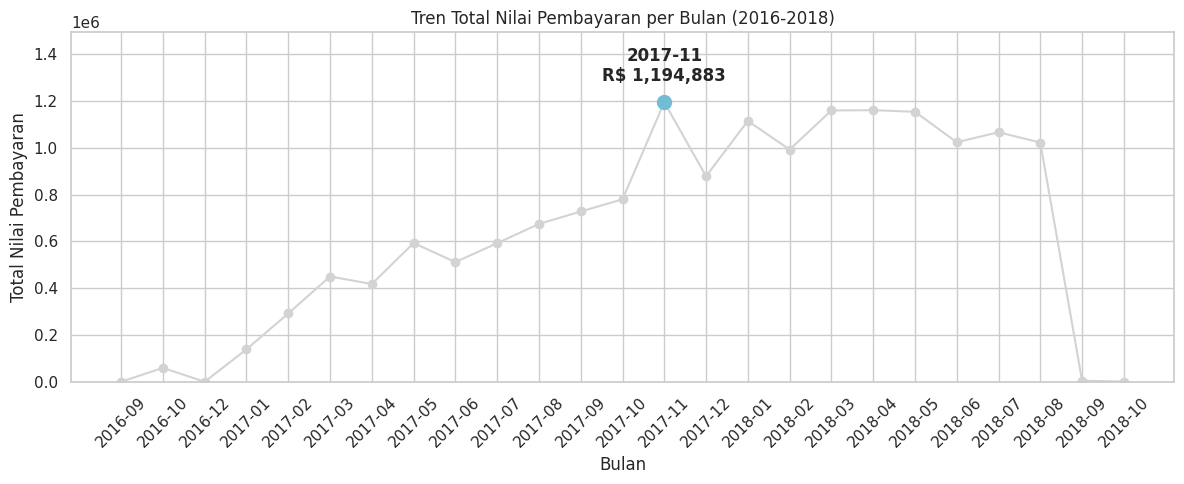

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(df_monthly_payment['month'], df_monthly_payment['payment_value'], marker='o', color='#D3D3D3')

peak_idx = df_monthly_payment['payment_value'].idxmax()
peak_month = df_monthly_payment.loc[peak_idx, 'month']
peak_value = df_monthly_payment.loc[peak_idx, 'payment_value']
plt.plot(peak_month, peak_value, marker='o', color='#72BCD4', markersize=10)
plt.annotate(f'{peak_month}\nR$ {peak_value:,.0f}', xy=(peak_month, peak_value),
             xytext=(0, 15), textcoords='offset points', ha='center', fontweight='bold')

plt.ylim(0, df_monthly_payment['payment_value'].max() * 1.25)  # beri ruang 25% di atas titik tertinggi
plt.xticks(rotation=45)
plt.title('Tren Total Nilai Pembayaran per Bulan (2016-2018)')
plt.xlabel('Bulan')
plt.ylabel('Total Nilai Pembayaran')
plt.tight_layout()
plt.show()

**Insight:**
- Order yang terlambat memiliki rata-rata `review score` yang jauh lebih rendah dibandingkan order yang tepat waktu, yaitu 2,57 vs 4,29. Hal ini menunjukkan bahwa keterlambatan pengiriman berkaitan dengan rendahnya kepuasan pelanggan.
- Kategori `office_furniture` memiliki rata-rata review score terendah, yaitu 3,65, dengan jumlah 1.241 order. Karena jumlah ordernya cukup besar, kategori ini dapat menjadi salah satu prioritas untuk mengevaluasi kualitas produk dan layanan.
- Total nilai pembayaran meningkat dari akhir 2016 hingga mencapai puncaknya pada November 2017 sebesar BRL 1.194.883. Setelah itu, nilai pembayaran tetap berada di kisaran BRL 1 juta hingga pertengahan 2018. Penurunan pada September–Oktober 2018 kemungkinan disebabkan oleh data pada periode tersebut yang belum lengkap.

## **Analisis Lanjutan (Opsional)**

### **RFM Analysis (Recency, Frequency, Monetary)**

In [25]:
reference_date = df_orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

df_customer_orders = df_orders.merge(df_customers[['customer_id', 'customer_unique_id']], on='customer_id')
df_customer_payment = df_customer_orders.merge(df_payments, on='order_id', how='left')

df_rfm = df_customer_payment.groupby('customer_unique_id').agg(
    last_purchase=('order_purchase_timestamp', 'max'),
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum')
).reset_index()

df_rfm['recency'] = (reference_date - df_rfm['last_purchase']).dt.days
df_rfm[['recency', 'frequency', 'monetary']].describe()

,recency,frequency,monetary
count,96096.000000,96096.000000,96096.000000
mean,288.735691,1.034809,166.592492
std,153.414676,0.214384,231.428332
min,1.000000,1.000000,0.000000
25%,164.000000,1.000000,63.120000
50%,269.000000,1.000000,108.000000
75%,398.000000,1.000000,183.530000
max,773.000000,17.000000,13664.080000


In [26]:
df_rfm['r_score'] = pd.qcut(df_rfm['recency'], 4, labels=[4, 3, 2, 1]).astype(int)
df_rfm['f_score'] = pd.qcut(df_rfm['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
df_rfm['m_score'] = pd.qcut(df_rfm['monetary'], 4, labels=[1, 2, 3, 4]).astype(int)
df_rfm['rfm_score'] = df_rfm['r_score'] + df_rfm['f_score'] + df_rfm['m_score']

def segment_customer(score):
    if score >= 10:
        return 'Top Customer'
    elif score >= 7:
        return 'Loyal Customer'
    elif score >= 5:
        return 'Potential/At Risk'
    else:
        return 'Hibernating/Lost'

df_rfm['segment'] = df_rfm['rfm_score'].apply(segment_customer)
segment_dist = df_rfm['segment'].value_counts()
segment_dist

,count
segment,
Loyal Customer,50044
Potential/At Risk,24122
Top Customer,15631
Hibernating/Lost,6299


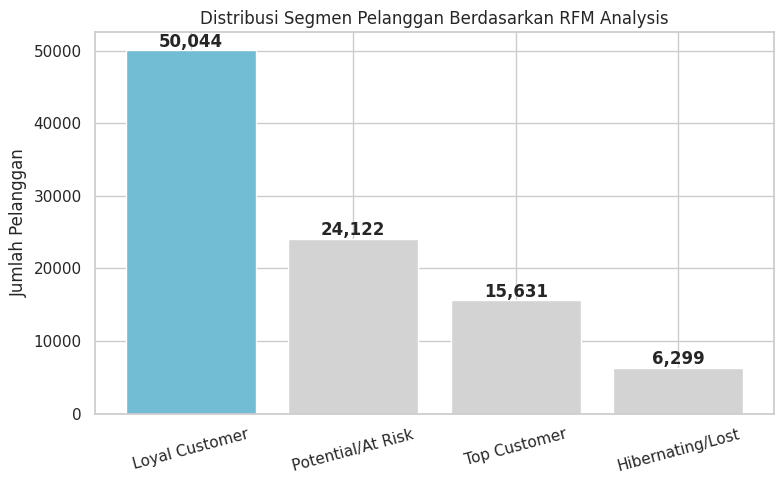

In [27]:
plt.figure(figsize=(8, 5))
colors_map = ['#72BCD4' if s == segment_dist.idxmax() else '#D3D3D3' for s in segment_dist.index]
plt.bar(segment_dist.index, segment_dist.values, color=colors_map)
plt.title('Distribusi Segmen Pelanggan Berdasarkan RFM Analysis')
plt.ylabel('Jumlah Pelanggan')
plt.xticks(rotation=15)
for i, v in enumerate(segment_dist.values):
    plt.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### **Geospatial Analysis: Waktu pengiriman per state**

In [28]:
df_delivered_state= df_delivered_orders.merge(df_customers[['customer_id', 'customer_state']], on='customer_id')

df_state_delivery = df_delivered_state.groupby('customer_state').agg(
    avg_delivery_days=('delivery_days', 'mean'),
    late_rate=('is_late', 'mean'),
    n_orders=('order_id', 'count')
).reset_index()

df_state_delivery = df_state_delivery[df_state_delivery['n_orders'] >= 50].sort_values('avg_delivery_days', ascending=False)
df_state_delivery.head(10)

,customer_state,avg_delivery_days,late_rate,n_orders
3,AP,26.731343,0.044776,67
2,AM,25.986207,0.041379,145
1,AL,24.040302,0.239295,397
13,PA,23.316068,0.123679,946
9,MA,21.117155,0.196653,717
24,SE,21.029851,0.152239,335
5,CE,20.817826,0.153245,1279
0,AC,20.637500,0.037500,80
14,PB,19.953578,0.110251,517
16,PI,18.993697,0.159664,476


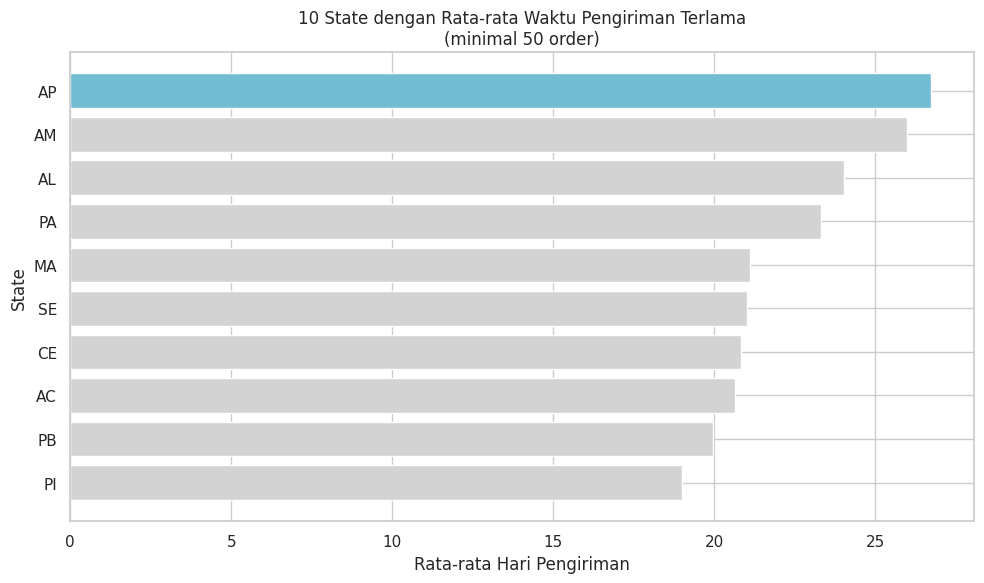

In [29]:
top10_worst = df_state_delivery.head(10)
colors_map = ['#72BCD4'] + ['#D3D3D3'] * 9  # highlight state terlama

plt.figure(figsize=(10, 6))
plt.barh(top10_worst['customer_state'][::-1], top10_worst['avg_delivery_days'][::-1], color=colors_map[::-1])
plt.title('10 State dengan Rata-rata Waktu Pengiriman Terlama\n(minimal 50 order)')
plt.xlabel('Rata-rata Hari Pengiriman')
plt.ylabel('State')
plt.tight_layout()
plt.show()

**Insight:**
- **RFM Analysis** digunakan untuk mengelompokkan pelanggan berdasarkan perilaku pembelian, seperti kapan terakhir berbelanja, seberapa sering berbelanja, dan total nilai pembeliannya. Hasil analisis menunjukkan bahwa **52,1% pelanggan termasuk Loyal Customer**, sedangkan **6,6% termasuk Hibernating/Lost** yang berisiko tidak melakukan pembelian lagi.
- **Geospatial Analysis** digunakan untuk melihat pola waktu pengiriman berdasarkan lokasi pelanggan. **State AP, AM, dan AL** memiliki rata-rata waktu pengiriman lebih dari **24 hari** yang jauh lebih lama dibandingkan rata-rata pengiriman di state dengan jumlah order besar seperti SP dan MG. Hal ini menunjukkan adanya tantangan dalam proses pengiriman di wilayah tersebut.

## **Conclusion & Recommendation**

- **Conclusion pertanyaan 1:** Keterlambatan pengiriman berkaitan dengan rendahnya kepuasan pelanggan. Rata-rata review score untuk **order terlambat hanya 2,57**, sedangkan **order tepat waktu mencapai 4,29**. Selain itu, kategori `office_furniture`, `fashion_male_clothing`, dan `audio` memiliki review score yang rendah meskipun jumlah ordernya cukup besar.
- **Conclusion pertanyaan 2:** Total nilai pembayaran menunjukkan peningkatan sejak akhir 2016 dan mencapai puncaknya pada November 2017, yaitu **lebih dari BRL 1,19 juta**. Nilai pembayaran kemudian tetap berada di atas BRL 1 juta per bulan hingga pertengahan 2018, sebelum mengalami penurunan pada September–Oktober 2018 karena data pada periode tersebut belum lengkap.

**Rekomendasi Action Item:**
- **Perbaiki proses pengiriman** pada state dengan waktu pengiriman terlama, seperti **AP, AM, AL, PA, dan MA**. Misalnya dengan menambah mitra kurir atau menggunakan gudang yang lebih dekat dengan pelanggan.
- **Evaluasi kategori produk dengan review score rendah**, terutama `office_furniture` dan `fashion_male_clothing` untuk mengetahui apakah masalah berasal dari kualitas produk, kemasan, atau ketidaksesuaian produk dengan ekspektasi pelanggan.
- **Buat strategi untuk mempertahankan pelanggan**, terutama pada segmen **Hibernating/Lost (6,6%)**, misalnya melalui promo win-back atau penawaran yang lebih personal. Sementara itu, pelanggan **Top Customer dan Loyal Customer** dapat dipertahankan melalui program loyalitas.
- **Manfaatkan periode dengan nilai transaksi tinggi**, terutama sekitar November dengan menyiapkan promosi musiman yang lebih besar untuk meningkatkan transaksi pada periode tersebut.

## **Membuat main_data untuk dashboard**

In [32]:
import os
from google.colab import files

# Membuat folder dashboard jika belum ada
os.makedirs('dashboard', exist_ok=True)

# Menyusun main_data.csv untuk kebutuhan dashboard Streamlit
df_main = df_delivered_orders.merge(
    df_customers[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']],
    on='customer_id', how='left'
)
df_main = df_main.merge(df_order_category, on='order_id', how='left')
df_main = df_main.merge(
    df_payments.groupby('order_id')['payment_value'].sum().reset_index(),
    on='order_id', how='left'
)
df_main = df_main.merge(df_reviews[['order_id', 'review_score']], on='order_id', how='left')

df_main = df_main[['order_id', 'customer_unique_id', 'customer_city', 'customer_state',
                    'order_purchase_timestamp', 'order_delivered_customer_date',
                    'order_estimated_delivery_date', 'is_late', 'delivery_days',
                    'product_category_name_english', 'payment_value', 'review_score']]

df_main.to_csv('dashboard/main_data.csv', index=False)
print("Shape:", df_main.shape)
df_main.head()

Shape: (97007, 12)


,order_id,customer_unique_id,customer_city,customer_state,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,is_late,delivery_days,product_category_name_english,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,False,8.0,housewares,38.71,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,barreiras,BA,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,False,13.0,perfumery,141.46,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,False,9.0,auto,179.12,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,False,13.0,pet_shop,72.20,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,False,2.0,stationery,28.62,5.0


In [33]:
files.download('dashboard/main_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>